# 02 · Data Understanding & EDA

**Phase goal:** know the data cold — shape, quality, the target's distribution, and which signals drive price — before modelling.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt
from car_pricing import config, data
raw = data.load_raw()
print('shape:', raw.shape)
raw.head()

shape: (19820, 17)


,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [2]:
print('Missing values per column:')
print(raw.isna().sum()[lambda s: s > 0] if raw.isna().any().any() else 'none')
print('\nDtypes:')
print(raw.dtypes)

Missing values per column:
none

Dtypes:
selling_price       float64
km_driven             int64
mileage             float64
engine              float64
max_power           float64
age                 float64
make                 object
model                object
Individual            int64
Trustmark Dealer      int64
Diesel                int64
Electric              int64
LPG                   int64
Petrol                int64
Manual                int64
5                     int64
>5                    int64
dtype: object


### The target: `selling_price` (in Lakhs)
Right-skewed, as resale prices usually are — most cars are cheap, a long tail of premium vehicles. This skew is why we report **MAE** (robust, intuitive in ₹) alongside R².

count    19820.00
mean         6.59
std          4.85
min          0.30
25%          3.41
50%          5.20
75%          7.85
max         20.90
Name: selling_price, dtype: float64


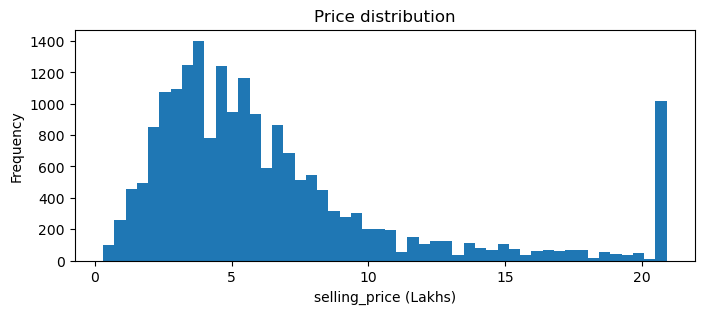

In [3]:
df = data.clean(raw)
print(df[config.TARGET].describe().round(2))
ax = df[config.TARGET].clip(upper=40).plot.hist(bins=50, figsize=(8,3))
ax.set_xlabel('selling_price (Lakhs)'); ax.set_title('Price distribution'); plt.show()

In [4]:
# Cardinality — the modelling challenge that drives feature engineering (nb 04)
print('distinct makes :', df['make'].nunique())
print('distinct models:', df['model'].nunique())
df.groupby('make')[config.TARGET].median().sort_values(ascending=False).head(8)

distinct makes : 41
distinct models: 3233


make
LEXUS            20.9025
JAGUAR           20.9025
BENTLEY          20.9025
BMW              20.9025
ROLLS-ROYCE      20.9025
PORSCHE          20.9025
MERCEDES-BENZ    20.9025
FERRARI          20.9025
Name: selling_price, dtype: float64

In [5]:
# Numeric drivers of price
num = config.NUMERIC + [config.TARGET]
df[num].corr()[config.TARGET].sort_values(ascending=False)

selling_price    1.000000
max_power        0.770390
engine           0.652296
km_driven       -0.100739
mileage         -0.314927
age             -0.390667
Name: selling_price, dtype: float64

### Findings that shape the pipeline
- **High cardinality:** ~3,200 distinct `model` values → one-hot would explode the feature space (addressed in nb 04 with target encoding).
- **Skewed target:** report MAE in ₹, not just R².
- **`max_power` / `engine` correlate strongly with price** → they must be filled sensibly at serve time (per-model medians), never dropped.